In [1]:
import os
import copy
import numpy as np
import pandas as pd
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms, models

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

In [2]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
GPU: NVIDIA GeForce RTX 3050 Laptop GPU


In [3]:
TRAIN_DIR = "../data/raw/Lung_Disease_Dataset/train"
VAL_DIR = "../data/raw/Lung_Disease_Dataset/val"

MODEL_DIR = "../models/Transfer_1"
os.makedirs(MODEL_DIR, exist_ok=True)

In [17]:
IMAGE_SIZE = 224
BATCH_SIZE = 32
NUM_CLASSES = 5

LEARNING_RATE = 1e-4
NUM_EPOCHS = 15

In [20]:
train_transforms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.RandomAffine(
    degrees=0,
    translate=(0.05, 0.05)
    ),
    transforms.ColorJitter(
        brightness=0.1,
        contrast=0.1
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
    
])

val_transforms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [6]:
train_dataset = datasets.ImageFolder(
    TRAIN_DIR,
    transform=train_transforms
)

val_dataset = datasets.ImageFolder(
    VAL_DIR,
    transform=val_transforms
)

print("Classes:", train_dataset.classes)
print("Train Samples:", len(train_dataset))
print("Val Samples:", len(val_dataset))

Classes: ['Bacterial Pneumonia', 'Corona Virus Disease', 'Normal', 'Tuberculosis', 'Viral Pneumonia']
Train Samples: 6054
Val Samples: 2016


In [7]:
train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=4,
    pin_memory=True
)

val_loader = torch.utils.data.DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=4,
    pin_memory=True
)

In [8]:
model = models.efficientnet_b0(
    weights=models.EfficientNet_B0_Weights.DEFAULT
)

In [9]:
for param in model.features.parameters():
    param.requires_grad = False

In [10]:
in_features = model.classifier[1].in_features

model.classifier = nn.Sequential(
    nn.Dropout(0.3),

    nn.Linear(in_features, 512),
    nn.ReLU(),
    nn.BatchNorm1d(512),

    nn.Dropout(0.3),

    nn.Linear(512, 256),
    nn.ReLU(),
    nn.BatchNorm1d(256),

    nn.Dropout(0.2),

    nn.Linear(256, NUM_CLASSES)
)

model = model.to(device)

print(model)

EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActivat

In [11]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(
    model.classifier.parameters(),
    lr=LEARNING_RATE
)

In [12]:
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=2
)

In [13]:
trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

total_params = sum(
    p.numel()
    for p in model.parameters()
)

print(f"Trainable: {trainable_params:,}")
print(f"Total: {total_params:,}")

Trainable: 790,021
Total: 4,797,569


In [14]:
def train_one_epoch(model, loader):

    model.train()

    running_loss = 0

    all_preds = []
    all_labels = []

    for images, labels in tqdm(loader):

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        preds = torch.argmax(outputs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    epoch_loss = running_loss / len(loader)

    acc = accuracy_score(all_labels, all_preds)

    return epoch_loss, acc

In [15]:
def validate(model, loader):

    model.eval()

    running_loss = 0

    all_preds = []
    all_labels = []

    with torch.no_grad():

        for images, labels in tqdm(loader):

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            running_loss += loss.item()

            preds = torch.argmax(outputs, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    epoch_loss = running_loss / len(loader)

    acc = accuracy_score(all_labels, all_preds)

    precision = precision_score(
        all_labels,
        all_preds,
        average="macro"
    )

    recall = recall_score(
        all_labels,
        all_preds,
        average="macro"
    )

    f1 = f1_score(
        all_labels,
        all_preds,
        average="macro"
    )

    return (
        epoch_loss,
        acc,
        precision,
        recall,
        f1
    )

In [ ]:

'''

history = {
    "train_loss": [],
    "val_loss": [],
    "val_acc": [],
    "val_precision": [],
    "val_recall": [],
    "val_f1": []
}

best_recall = 0

best_model_path = os.path.join(
    MODEL_DIR,
    "efficientnet_head_best.pth"
)

for epoch in range(NUM_EPOCHS):

    print(f"\nEpoch {epoch+1}/{NUM_EPOCHS}")

    train_loss, train_acc = train_one_epoch(
        model,
        train_loader
    )

    (
        val_loss,
        val_acc,
        val_precision,
        val_recall,
        val_f1
    ) = validate(
        model,
        val_loader
    )

    scheduler.step(val_recall)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    history["val_precision"].append(val_precision)
    history["val_recall"].append(val_recall)
    history["val_f1"].append(val_f1)

    print(f"Train Loss: {train_loss:.4f}")
    print(f"Val Loss: {val_loss:.4f}")
    print(f"Val Recall: {val_recall:.4f}")
    print(f"Val F1: {val_f1:.4f}")

    if val_recall > best_recall:

        best_recall = val_recall

        torch.save({
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "recall": val_recall,
            "f1": val_f1
        }, best_model_path)

        print("✅ Best Model Saved")


        '''


Epoch 1/15


100%|██████████| 63/63 [00:54<00:00,  1.16it/s]


Train Loss: 0.6526
Val Loss: 0.5742
Val Recall: 0.7949
Val F1: 0.7838
✅ Best Model Saved

Epoch 2/15


100%|██████████| 63/63 [00:53<00:00,  1.19it/s]


Train Loss: 0.5428
Val Loss: 0.8991
Val Recall: 0.7790
Val F1: 0.7699

Epoch 3/15


...

Train Loss: 0.4040
Val Loss: 0.4497
Val Recall: 0.8396
Val F1: 0.8354
✅ Best Model Saved

Epoch 14/15


100%|██████████| 63/63 [00:59<00:00,  1.06it/s]


Train Loss: 0.4012
Val Loss: 0.4509
Val Recall: 0.8166
Val F1: 0.8113

Epoch 15/15


100%|██████████| 63/63 [00:59<00:00,  1.06it/s]


Train Loss: 0.3925
Val Loss: 0.5083
Val Recall: 0.8431
Val F1: 0.8412
✅ Best Model Saved


In [27]:
checkpoint = torch.load(
    os.path.join(MODEL_DIR, "efficientnet_head_best.pth"),
    map_location=device
)

print(type(checkpoint))

if isinstance(checkpoint, dict):
    print(checkpoint.keys())

<class 'dict'>
dict_keys(['epoch', 'model_state_dict', 'optimizer_state_dict', 'recall', 'f1'])


In [28]:
checkpoint = torch.load(
    os.path.join(MODEL_DIR, "efficientnet_head_best.pth"),
    map_location=device
)

model.load_state_dict(
    checkpoint["model_state_dict"]
)

model.eval()

print("Best model loaded successfully!")

Best model loaded successfully!


In [30]:
import pandas as pd
import os

history_df = pd.DataFrame(history)

history_path = os.path.join(
    MODEL_DIR,
    "efficientnet_head_history.csv"
)

history_df.to_csv(
    history_path,
    index=False
)

print(f"History saved to: {history_path}")

History saved to: ../models/Transfer_1\efficientnet_head_history.csv


In [32]:
all_preds = []
all_labels = []

model.eval()

with torch.no_grad():

    for images, labels in val_loader:

        images = images.to(device)

        outputs = model(images)

        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

In [35]:
print(train_dataset.classes)

['Bacterial Pneumonia', 'Corona Virus Disease', 'Normal', 'Tuberculosis', 'Viral Pneumonia']


In [36]:
class_names = train_dataset.classes

In [37]:
from sklearn.metrics import classification_report
import pandas as pd
import os

report = classification_report(
    all_labels,
    all_preds,
    target_names=class_names,
    output_dict=True
)

report_df = pd.DataFrame(report).transpose()

report_df.to_csv(
    os.path.join(
        MODEL_DIR,
        "classification_report.csv"
    )
)

print(report_df)

                      precision    recall  f1-score     support
Bacterial Pneumonia    0.780186  0.628429  0.696133   401.00000
Corona Virus Disease   0.934118  0.977833  0.955475   406.00000
Normal                 0.867749  0.930348  0.897959   402.00000
Tuberculosis           0.982368  0.960591  0.971357   406.00000
Viral Pneumonia        0.654545  0.718204  0.684899   401.00000
accuracy               0.843750  0.843750  0.843750     0.84375
macro avg              0.843793  0.843081  0.841165  2016.00000
weighted avg           0.844373  0.843750  0.841799  2016.00000


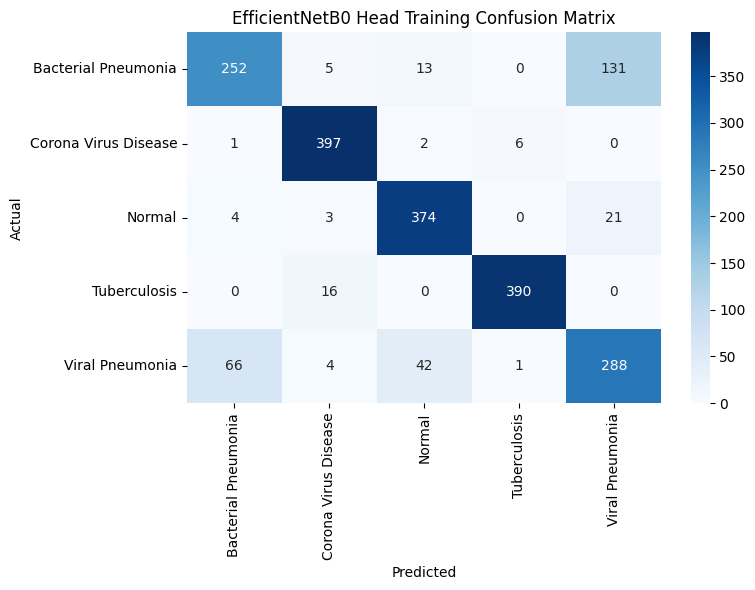

In [38]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(
    all_labels,
    all_preds
)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("EfficientNetB0 Head Training Confusion Matrix")

plt.tight_layout()

plt.savefig(
    os.path.join(
        MODEL_DIR,
        "confusion_matrix.png"
    )
)

plt.show()

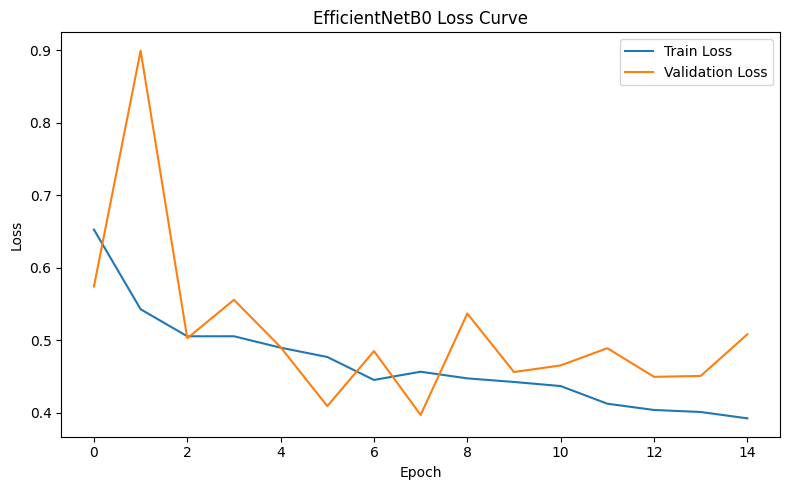

In [39]:
plt.figure(figsize=(8,5))

plt.plot(
    history["train_loss"],
    label="Train Loss"
)

plt.plot(
    history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("EfficientNetB0 Loss Curve")

plt.legend()

plt.tight_layout()

plt.savefig(
    os.path.join(
        MODEL_DIR,
        "loss_curve.png"
    )
)

plt.show()

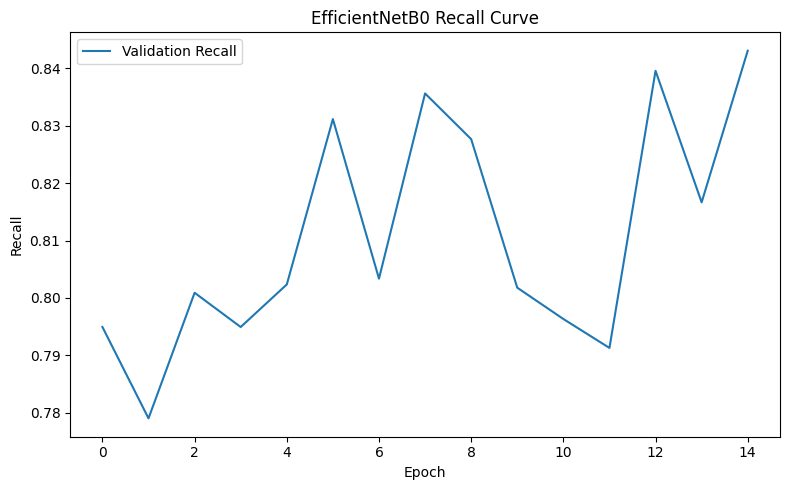

In [40]:
plt.figure(figsize=(8,5))

plt.plot(
    history["val_recall"],
    label="Validation Recall"
)

plt.xlabel("Epoch")
plt.ylabel("Recall")
plt.title("EfficientNetB0 Recall Curve")

plt.legend()

plt.tight_layout()

plt.savefig(
    os.path.join(
        MODEL_DIR,
        "recall_curve.png"
    )
)

plt.show()

In [41]:
best_epoch = history["val_f1"].index(
    max(history["val_f1"])
) + 1

with open(
    os.path.join(
        MODEL_DIR,
        "metrics.txt"
    ),
    "w"
) as f:

    f.write("EfficientNetB0 Head Training Results\n")
    f.write("="*50 + "\n\n")

    f.write(f"Best Epoch: {best_epoch}\n")
    f.write(f"Best Recall: {max(history['val_recall']):.4f}\n")
    f.write(f"Best F1: {max(history['val_f1']):.4f}\n")
    f.write(f"Final Val Loss: {history['val_loss'][-1]:.4f}\n")

print("Metrics saved")

Metrics saved


In [42]:
import json

with open(
    os.path.join(
        MODEL_DIR,
        "class_names.json"
    ),
    "w"
) as f:

    json.dump(class_names, f)

print("Class names saved")

Class names saved
